In [11]:
import torch, torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
from torch.utils.data import DataLoader,Subset
import matplotlib.pyplot as plt

In [12]:
t = T.Compose([T.ToTensor(), T.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))])
trd = DataLoader(Subset(torchvision.datasets.CIFAR10('./data', train=True, transform=t, download=True),range(2000)),batch_size=64,shuffle=True)
ted = DataLoader(Subset(torchvision.datasets.CIFAR10('./data', False, download=True, transform=t),range(50)),64)

Files already downloaded and verified
Files already downloaded and verified


In [13]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(4096,128), nn.ReLU(), nn.Linear(128,10)
        )
    def forward(self,x):
        return self.net(x)

In [19]:
def train(model, opt, crit, epochs=5):
    trl, tel, acl = [], [], []
    for e in range(epochs):
        model.train()
        rl=0
        for x,y in trd:
            opt.zero_grad()
            o=model(x)
            l=crit(o,y)
            l.backward()
            opt.step()
            rl += l.item()

        model.eval()
        tl=0
        c=0
        n=0
        with torch.no_grad():
            for x,y in ted:
                o = model(x)
                l=crit(o,y)
                tl += l.item()
                c += (o.argmax(1)==y).sum().item()
                n += len(y)
        trl.append(rl/len(trd))
        tel.append(tl/len(ted))
        acl.append(c/n)
        print(f'Epoch {e+1} | Train Loss: {rl/len(trd)} | Test Loss: {tl/len(ted)} | Accuracy: {c/n:.2f}')
    return trl,tel,acl


In [20]:
crit = nn.CrossEntropyLoss()
ms = CNN()
ma = CNN()
print('SGD')
trs, tls, acs = train(ms,optim.SGD(ms.parameters(), 0.01, momentum=0.9),crit)
print('Adam')
tra, tla, aca = train(ma, optim.Adam(ma.parameters(),1e-3),crit)

SGD
Epoch 1 | Train Loss: 2.199981238692999 | Test Loss: 1.8280847072601318 | Accuracy: 0.44
Epoch 2 | Train Loss: 1.9141304306685925 | Test Loss: 1.8246501684188843 | Accuracy: 0.32
Epoch 3 | Train Loss: 1.7278640158474445 | Test Loss: 1.516210913658142 | Accuracy: 0.58
Epoch 4 | Train Loss: 1.5732281804084778 | Test Loss: 1.5075597763061523 | Accuracy: 0.34
Epoch 5 | Train Loss: 1.4715068750083447 | Test Loss: 1.3910199403762817 | Accuracy: 0.48
Adam
Epoch 1 | Train Loss: 1.929310653358698 | Test Loss: 1.5599677562713623 | Accuracy: 0.50
Epoch 2 | Train Loss: 1.576291311532259 | Test Loss: 1.4805880784988403 | Accuracy: 0.44
Epoch 3 | Train Loss: 1.362719815224409 | Test Loss: 1.3465653657913208 | Accuracy: 0.48
Epoch 4 | Train Loss: 1.1723393313586712 | Test Loss: 1.381743311882019 | Accuracy: 0.52
Epoch 5 | Train Loss: 0.9837140329182148 | Test Loss: 1.607926368713379 | Accuracy: 0.32


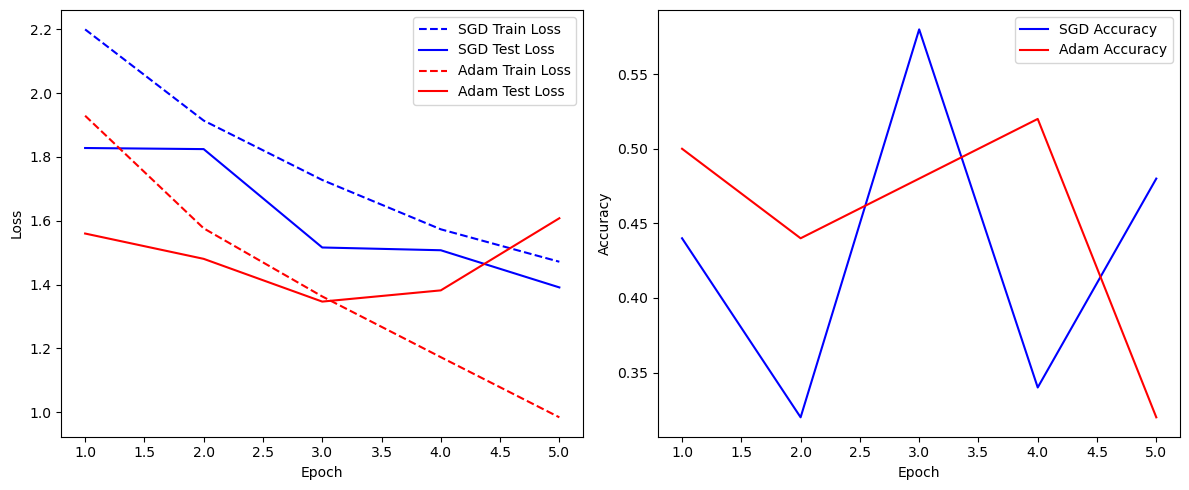

In [22]:
ep = range(1,6)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)

plt.plot(ep,trs,'b--',label='SGD Train Loss')
plt.plot(ep,tls,'b-',label='SGD Test Loss')
plt.plot(ep,tra,'r--',label='Adam Train Loss')
plt.plot(ep,tla,'r-',label='Adam Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(ep,acs,'b-',label='SGD Accuracy')
plt.plot(ep,aca,'r-',label='Adam Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()